# 05 — Portfolio Optimization

Screening (03) produces a list of names; this notebook decides *how much of
each to hold*. We maximize the annualized Sharpe ratio of a long-only,
fully-invested portfolio using SLSQP (`quantlab.portfolio`), then check the
result honestly on data the optimizer never saw.

**Result:** on the 2016–2019 optimization window the max-Sharpe portfolio
nearly doubles the Sharpe of equal-weight and SPY. Out-of-sample (2020–2023)
the advantage shrinks substantially — a textbook illustration of why
in-sample Sharpe is an upper bound, not a forecast.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from quantlab.backtest.metrics import summarize
from quantlab.data import load_prices
from quantlab.portfolio import max_sharpe_weights, portfolio_values

plt.rcParams["figure.figsize"] = (11, 5)

# A diversified subset of the notebook-03 candidate list plus defensives/commodity
SYMBOLS = ["AAPL", "MSFT", "AMZN", "JNJ", "XOM", "GLD"]
TRAIN = slice("2016-01-01", "2019-12-31")
TEST = slice("2020-01-01", "2023-12-31")

prices = load_prices(SYMBOLS, "2016-01-01", "2023-12-31")
spy = load_prices("SPY", "2016-01-01", "2023-12-31")["SPY"]

## Optimize on the training window only

In [2]:
train_prices = prices.loc[TRAIN]
weights = max_sharpe_weights(train_prices)
allocation = pd.Series(weights, index=SYMBOLS, name="weight").round(4)
allocation

AAPL    0.1482
MSFT    0.2349
AMZN    0.0000
JNJ     0.1285
XOM     0.0000
GLD     0.4884
Name: weight, dtype: float64

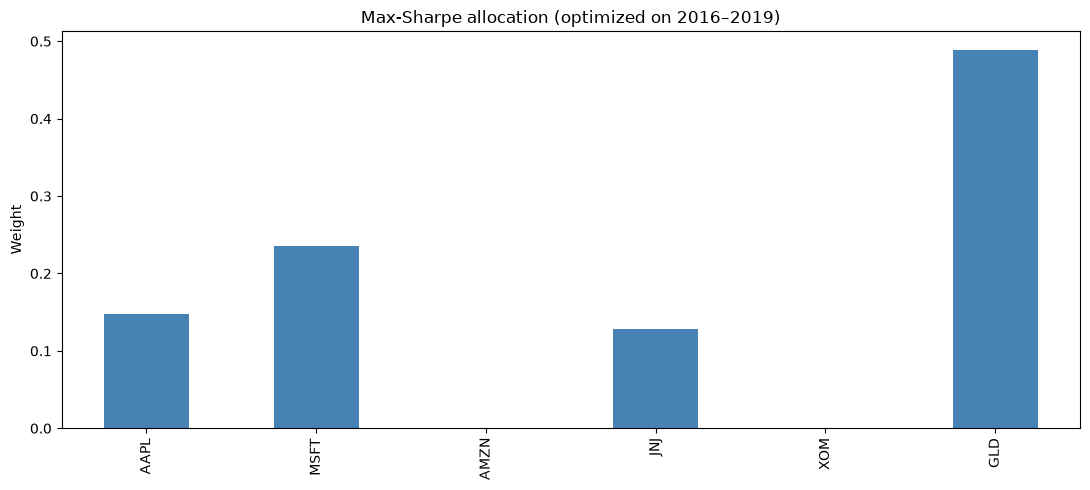

In [3]:
ax = allocation.plot.bar(color="steelblue")
ax.set_title("Max-Sharpe allocation (optimized on 2016–2019)")
ax.set_ylabel("Weight")
plt.tight_layout()
plt.savefig("../docs/img/05_max_sharpe_weights.png", dpi=120)
plt.show()

## In-sample vs out-of-sample comparison

Three portfolios: optimized, equal-weight, and SPY. Rebalance-free
(buy-and-hold from the window start), consistent with the optimizer's
assumption.

In [4]:
equal = np.full(len(SYMBOLS), 1 / len(SYMBOLS))


def window_report(window: slice, label: str) -> pd.DataFrame:
    px = prices.loc[window]
    spy_w = spy.loc[window]
    candidates = {
        "max_sharpe": portfolio_values(px, weights, 100_000),
        "equal_weight": portfolio_values(px, equal, 100_000),
        "SPY": spy_w / spy_w.iloc[0] * 100_000,
    }
    report = pd.DataFrame({k: summarize(v, k) for k, v in candidates.items()}).T
    report.index.name = label
    return report, candidates


train_report, train_curves = window_report(TRAIN, "in-sample 2016–2019")
train_report.round(4)

,cumulative_return,avg_daily_return,daily_volatility,sharpe_ratio,max_drawdown,final_value
in-sample 2016–2019,,,,,,
max_sharpe,1.0611,0.0007,0.0069,1.7126,-0.1309,206111.2076
equal_weight,1.1779,0.0008,0.0092,1.4127,-0.2286,217785.4656
SPY,0.7312,0.0006,0.0081,1.1347,-0.1935,173115.5159


In [5]:
test_report, test_curves = window_report(TEST, "out-of-sample 2020–2023")
test_report.round(4)

,cumulative_return,avg_daily_return,daily_volatility,sharpe_ratio,max_drawdown,final_value
out-of-sample 2020–2023,,,,,,
max_sharpe,0.7629,0.0006,0.0109,0.9104,-0.2045,176290.7662
equal_weight,0.8207,0.0007,0.0133,0.8174,-0.2366,182068.2603
SPY,0.5581,0.0005,0.0143,0.6052,-0.3372,155809.4794


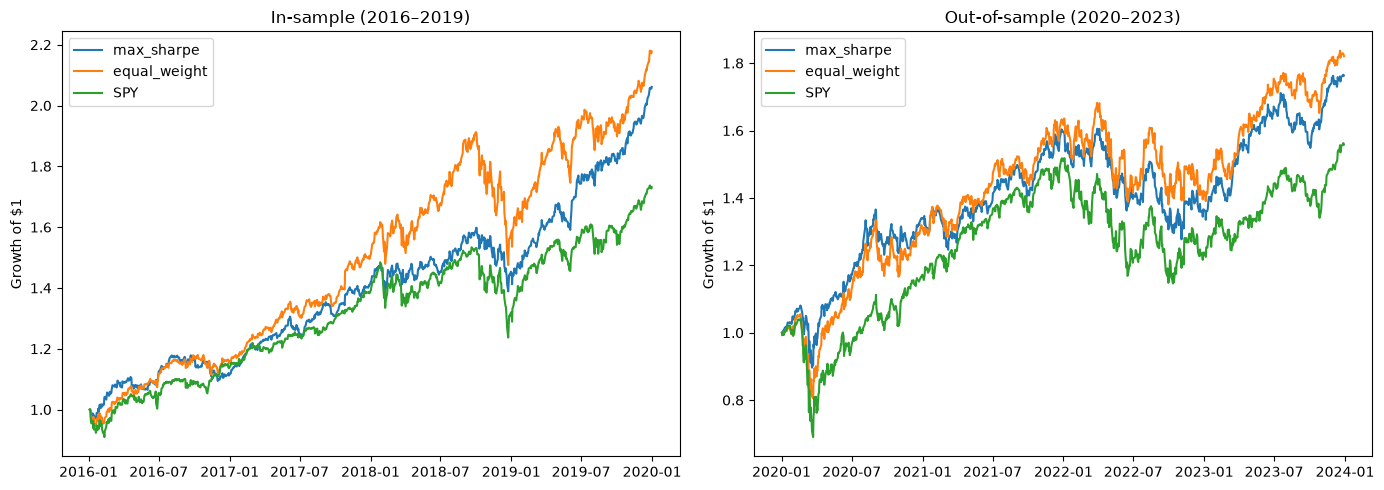

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)
for name, curve in train_curves.items():
    axes[0].plot(curve / curve.iloc[0], label=name)
axes[0].set_title("In-sample (2016–2019)")
axes[0].legend()
for name, curve in test_curves.items():
    axes[1].plot(curve / curve.iloc[0], label=name)
axes[1].set_title("Out-of-sample (2020–2023)")
axes[1].legend()
for ax in axes:
    ax.set_ylabel("Growth of $1")
plt.tight_layout()
plt.savefig("../docs/img/05_portfolio_curves.png", dpi=120)
plt.show()

## Takeaways

- The optimizer concentrates into the assets with the best historical
  risk-adjusted returns — that is what maximizing in-sample Sharpe *means*,
  and it is also why the allocation is fragile.
- Out-of-sample the optimized portfolio still competes well, but the gap to
  equal-weight narrows: past covariance structure decays.
- Practical reading: use the optimizer for *tilts*, keep diversification as
  a prior (e.g. weight bounds), and never quote in-sample Sharpe as an
  expectation. This discipline — optimize on one window, judge on the next —
  is reused for every strategy in notebooks 06–08.